In [3]:
import numpy as np
import pandas as pd
import subprocess
import os
import sys
import argparse
import glob
import time
from astropy.io import fits as pyfits
import matplotlib.pyplot as plt
from urllib.request import urlopen
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.time import Time
from contextlib import closing
from astropy import units as u

In [4]:
full_df = pd.read_csv('final_full_data_centered.csv')

In [5]:
detections_ids = [
    "ZTF18acbwopo",
    "ZTF18acpdvos",
    "ZTF19aakkths",
    "ZTF19aakswrb",
    "ZTF19abpidqn",
    "ZTF19abucwzt",
    "ZTF19abxqppy",
    "ZTF19acxxwvi",
    "ZTF19adaxzax",
    "ZTF19adcfsad",
    "ZTF20aaieyup",
    "ZTF20abegirf",
    "ZTF20acaazkt",
    "ZTF20acnvniw",
    "ZTF20acytgxf",
    "ZTF21aagtpro",
    "ZTF21ablwehd",
    "ZTF21abzciqh",
    "ZTF22aaagrce",
    "ZTF22abajudi",
    "ZTF23aabngtm",
    "ZTF23aaqdjhi",
    "ZTF23abbccir",
    "ZTF24aahgqwk",
    # Adding the two non-detected but known TDEs
    'ZTF17aaazdba',
    'ZTF19abzrhgq',
]


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

plt.rc('text', usetex=True)

def sci_fmt(x):
    if pd.isna(x):
        return "NaN"
    return f"{x:.2e}"

def load_array_from_path(path):
    if pd.isna(path) or path is None:
        return None
    return np.load(path)

def plot_detection_objects_six_wide(
    full_df,
    detections_ids,
    *,
    iau_csv_path="jacks-ztf-transients.csv",
    name_col="Name",
    epoch_col="Epoch",
    path_col="File Path",
    dt_col="Rest_DeltaT",
    rms_col="RMS",
    peak_col="Peak Luminosity",
    type_col="type",
    cmap="inferno",
    savepath=None,
    individual_scaling=True,
    figsize_per_panel=(2.8, 3.5),
    title_fontsize=17,
    dt_fontsize=17,
    label_fontsize=17,
    tickless_spine_width=1.2
):
    # --- read the ZTFID -> IAUID mapping ---
    iau_df = pd.read_csv(iau_csv_path)
    ztf_to_iau = dict(zip(iau_df["ZTFID"], iau_df["IAUID"]))

    sub = full_df[full_df[name_col].isin(detections_ids)].copy()

    if sub.empty:
        raise ValueError("No rows matched detections_ids.")

    sub = sub.sort_values([name_col, epoch_col]).reset_index(drop=True)
    object_names = sub[name_col].drop_duplicates().tolist()

    objects_per_row = 2
    nrows = math.ceil(len(object_names) / objects_per_row)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=7,
        figsize=(figsize_per_panel[0] * 6.4, figsize_per_panel[1] * nrows),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.35, 1, 1, 1]}
    )

    axes = np.atleast_2d(axes)
    if nrows == 1:
        axes = axes.reshape(1, -1)

    im_for_cbar = None

    # spacer column off
    for i in range(nrows):
        axes[i, 3].axis("off")

    for obj_idx, obj in enumerate(object_names):
        row_block = obj_idx // objects_per_row
        col_block = obj_idx % objects_per_row
        start_col = 0 if col_block == 0 else 4

        obj_df = sub[sub[name_col] == obj].copy().sort_values(epoch_col)
        epoch_map = {int(row[epoch_col]): row for _, row in obj_df.iterrows()}

        obj_type = obj_df[type_col].iloc[0] if type_col in obj_df.columns else ""
        display_name = ztf_to_iau.get(obj, obj)
        group_label = f"{display_name} ({obj_type})" if obj_type else display_name

        for j, epoch in enumerate([1, 2, 3]):
            ax = axes[row_block, start_col + j]

            if epoch not in epoch_map:
                ax.axis("off")
                continue

            row = epoch_map[epoch]
            arr = load_array_from_path(row[path_col])

            if arr is None:
                ax.axis("off")
                continue

            rms = row[rms_col]

            # convert to signal-to-noise units
            plot_arr = arr / rms

            # fixed scale in sigma units
            vmin = -2
            vmax = 8

            rms = row[rms_col]
            peakL = row[peak_col]
            dt = row[dt_col]

            im = ax.imshow(
                plot_arr,
                cmap=cmap,
                interpolation="nearest",
                vmin=vmin,
                vmax=vmax,
                origin='lower'
            )

            if im_for_cbar is None:
                im_for_cbar = im

            if j == 1:
                ax.set_title(
                    group_label + "\n" + rf"$\Delta t = {dt:.1f}\,\mathrm{{d}}$",
                    fontsize=title_fontsize,
                    weight="bold"
                )
            else:
                ax.set_title(
                    rf"$\Delta t = {dt:.1f}\,\mathrm{{d}}$",
                    fontsize=dt_fontsize
                )

            label = (
                rf"$L_{{\max}} = {sci_fmt(peakL)}$" "\n"
                rf"$\mathrm{{RMS}} = {sci_fmt(rms)}$"
            )
            # ax.set_xlabel(label, fontsize=label_fontsize, labelpad=12, ha="center")
            # ax.xaxis.label.set_linespacing(1.4)

            ax.tick_params(
                left=False, bottom=False,
                labelleft=False, labelbottom=False
            )

            for spine in ax.spines.values():
                spine.set_linewidth(tickless_spine_width)
                spine.set_edgecolor("black")

    # turn off unused object slots
    total_slots = nrows * objects_per_row
    for empty_idx in range(len(object_names), total_slots):
        row_block = empty_idx // objects_per_row
        col_block = empty_idx % objects_per_row
        start_col = 0 if col_block == 0 else 4
        for j in range(3):
            axes[row_block, start_col + j].axis("off")

    plt.subplots_adjust(
        left=0.035, right=0.92, top=0.94, bottom=0.07,
        hspace=0.1, wspace=0.06
    )

    cbar = fig.colorbar(
        im_for_cbar,
        ax=axes.ravel().tolist(),
        fraction=0.03,
        pad=0.02
    )

    cbar.set_label("S/N", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()
    return fig, axes

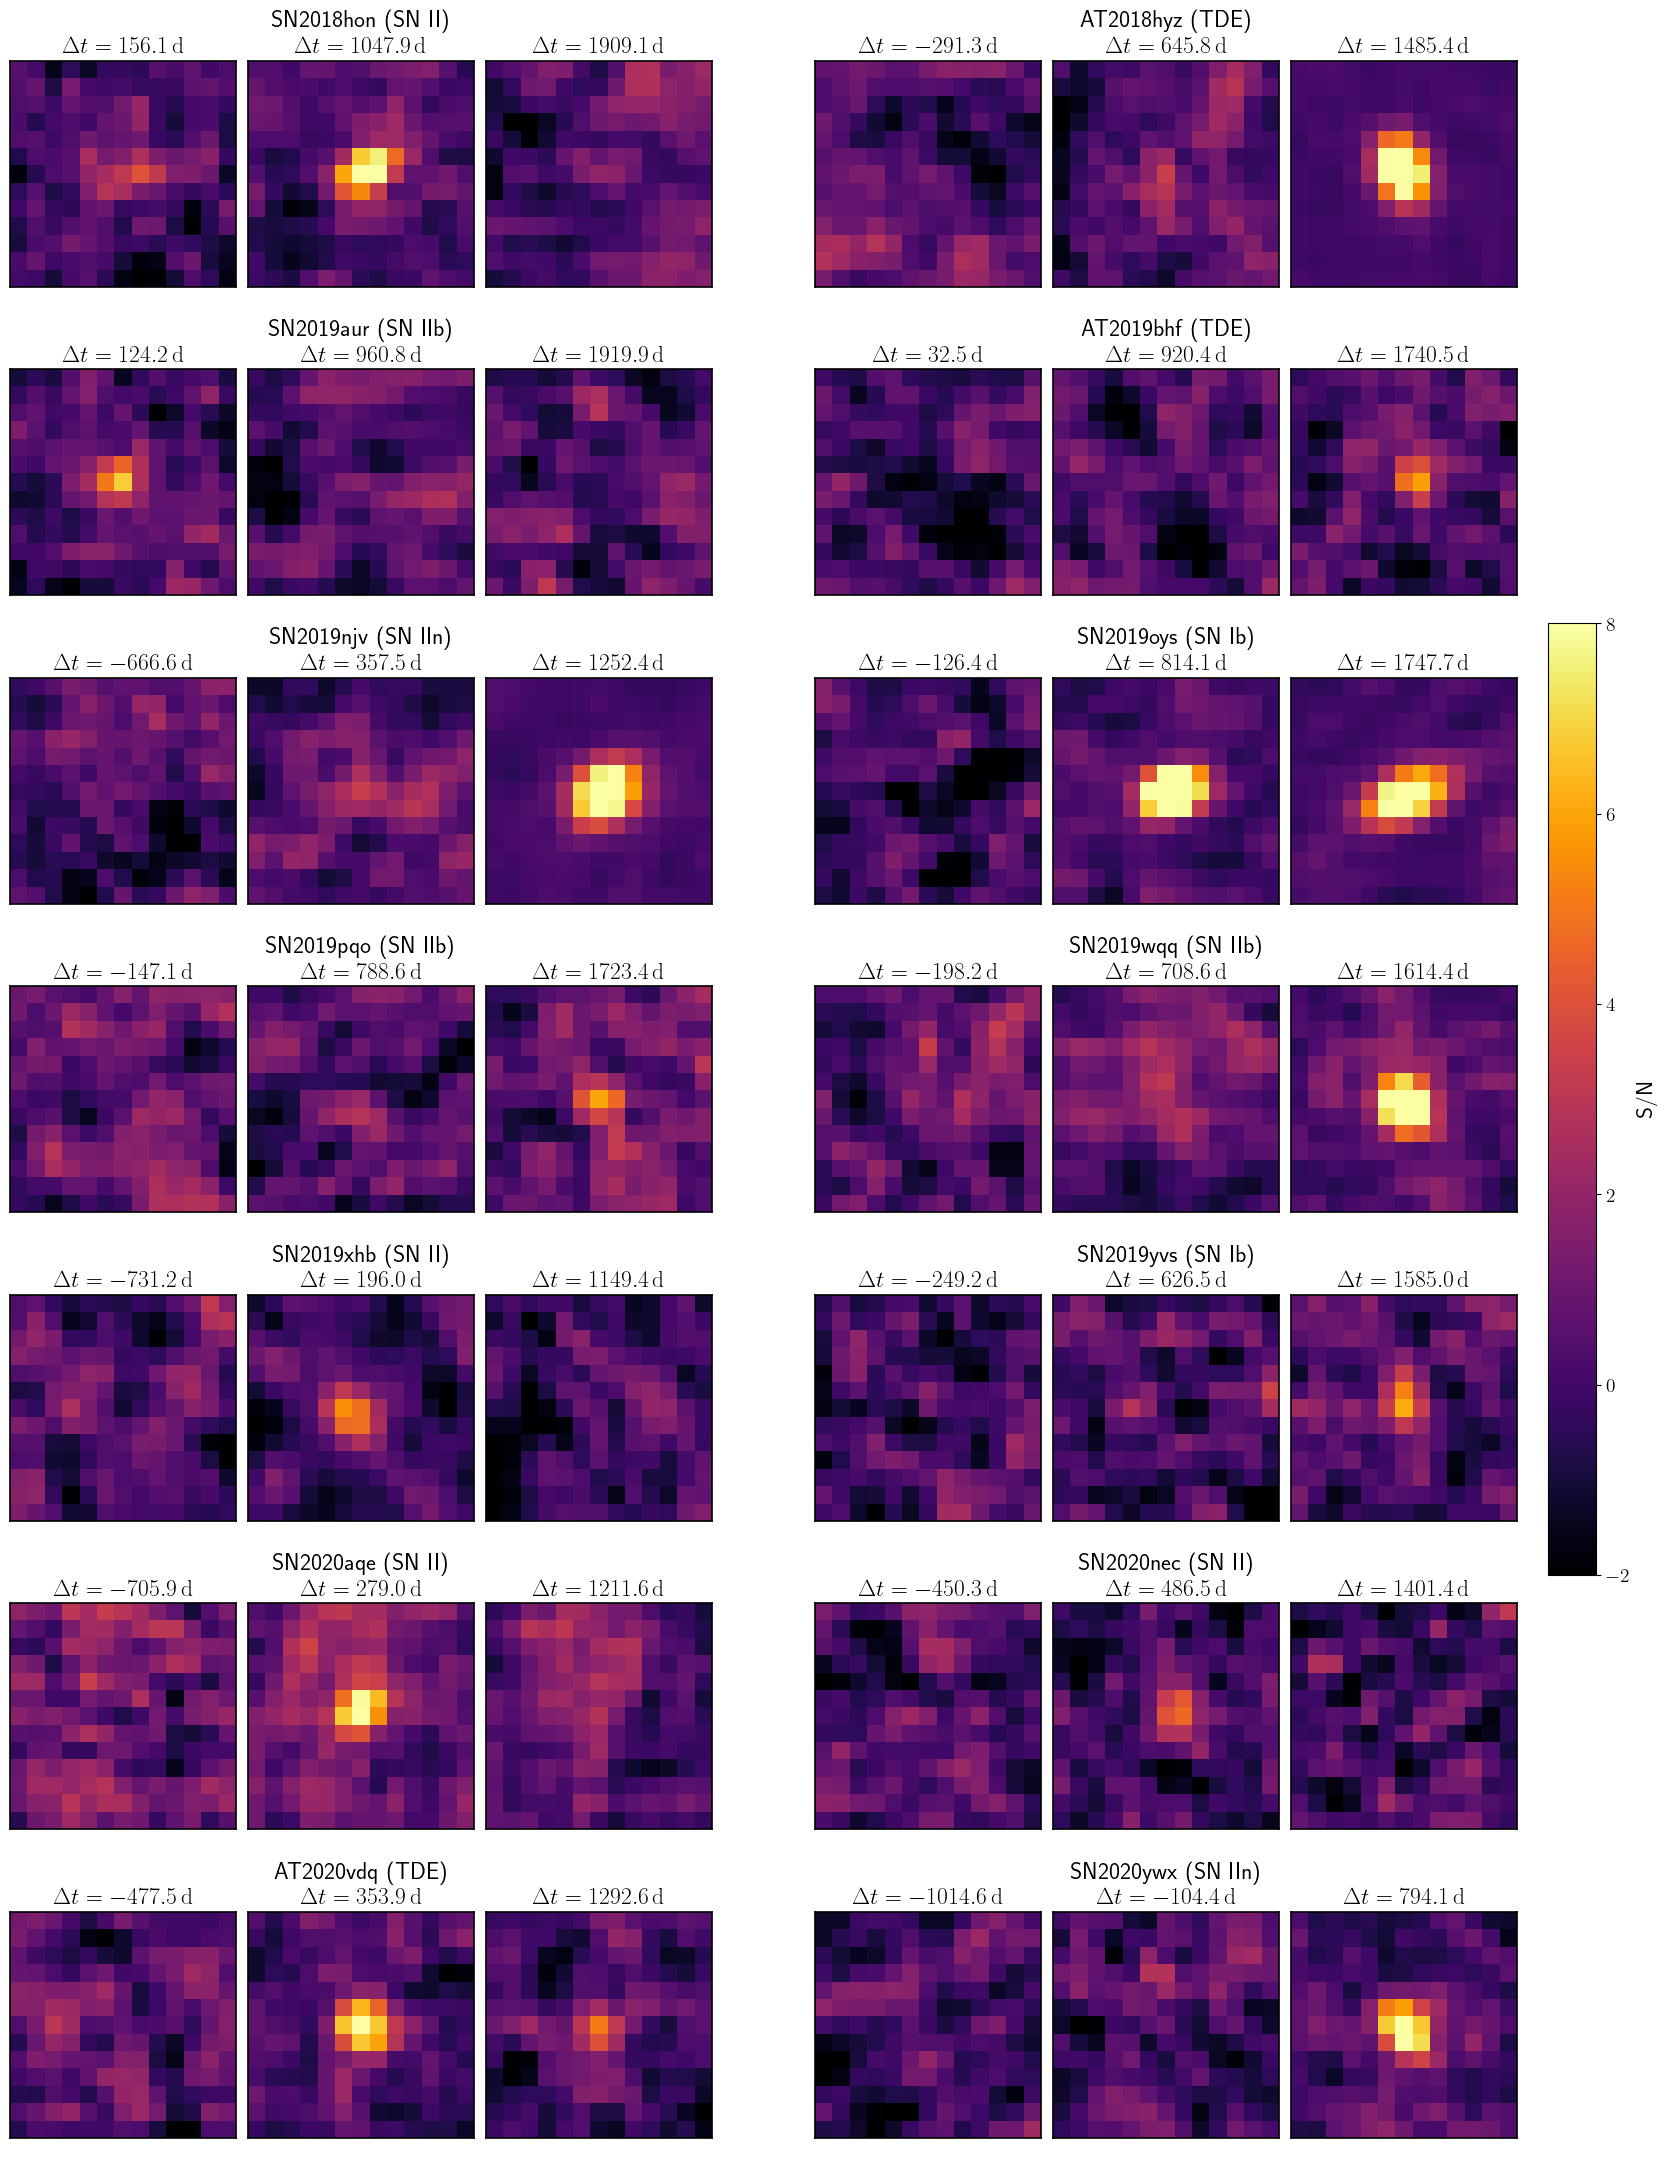

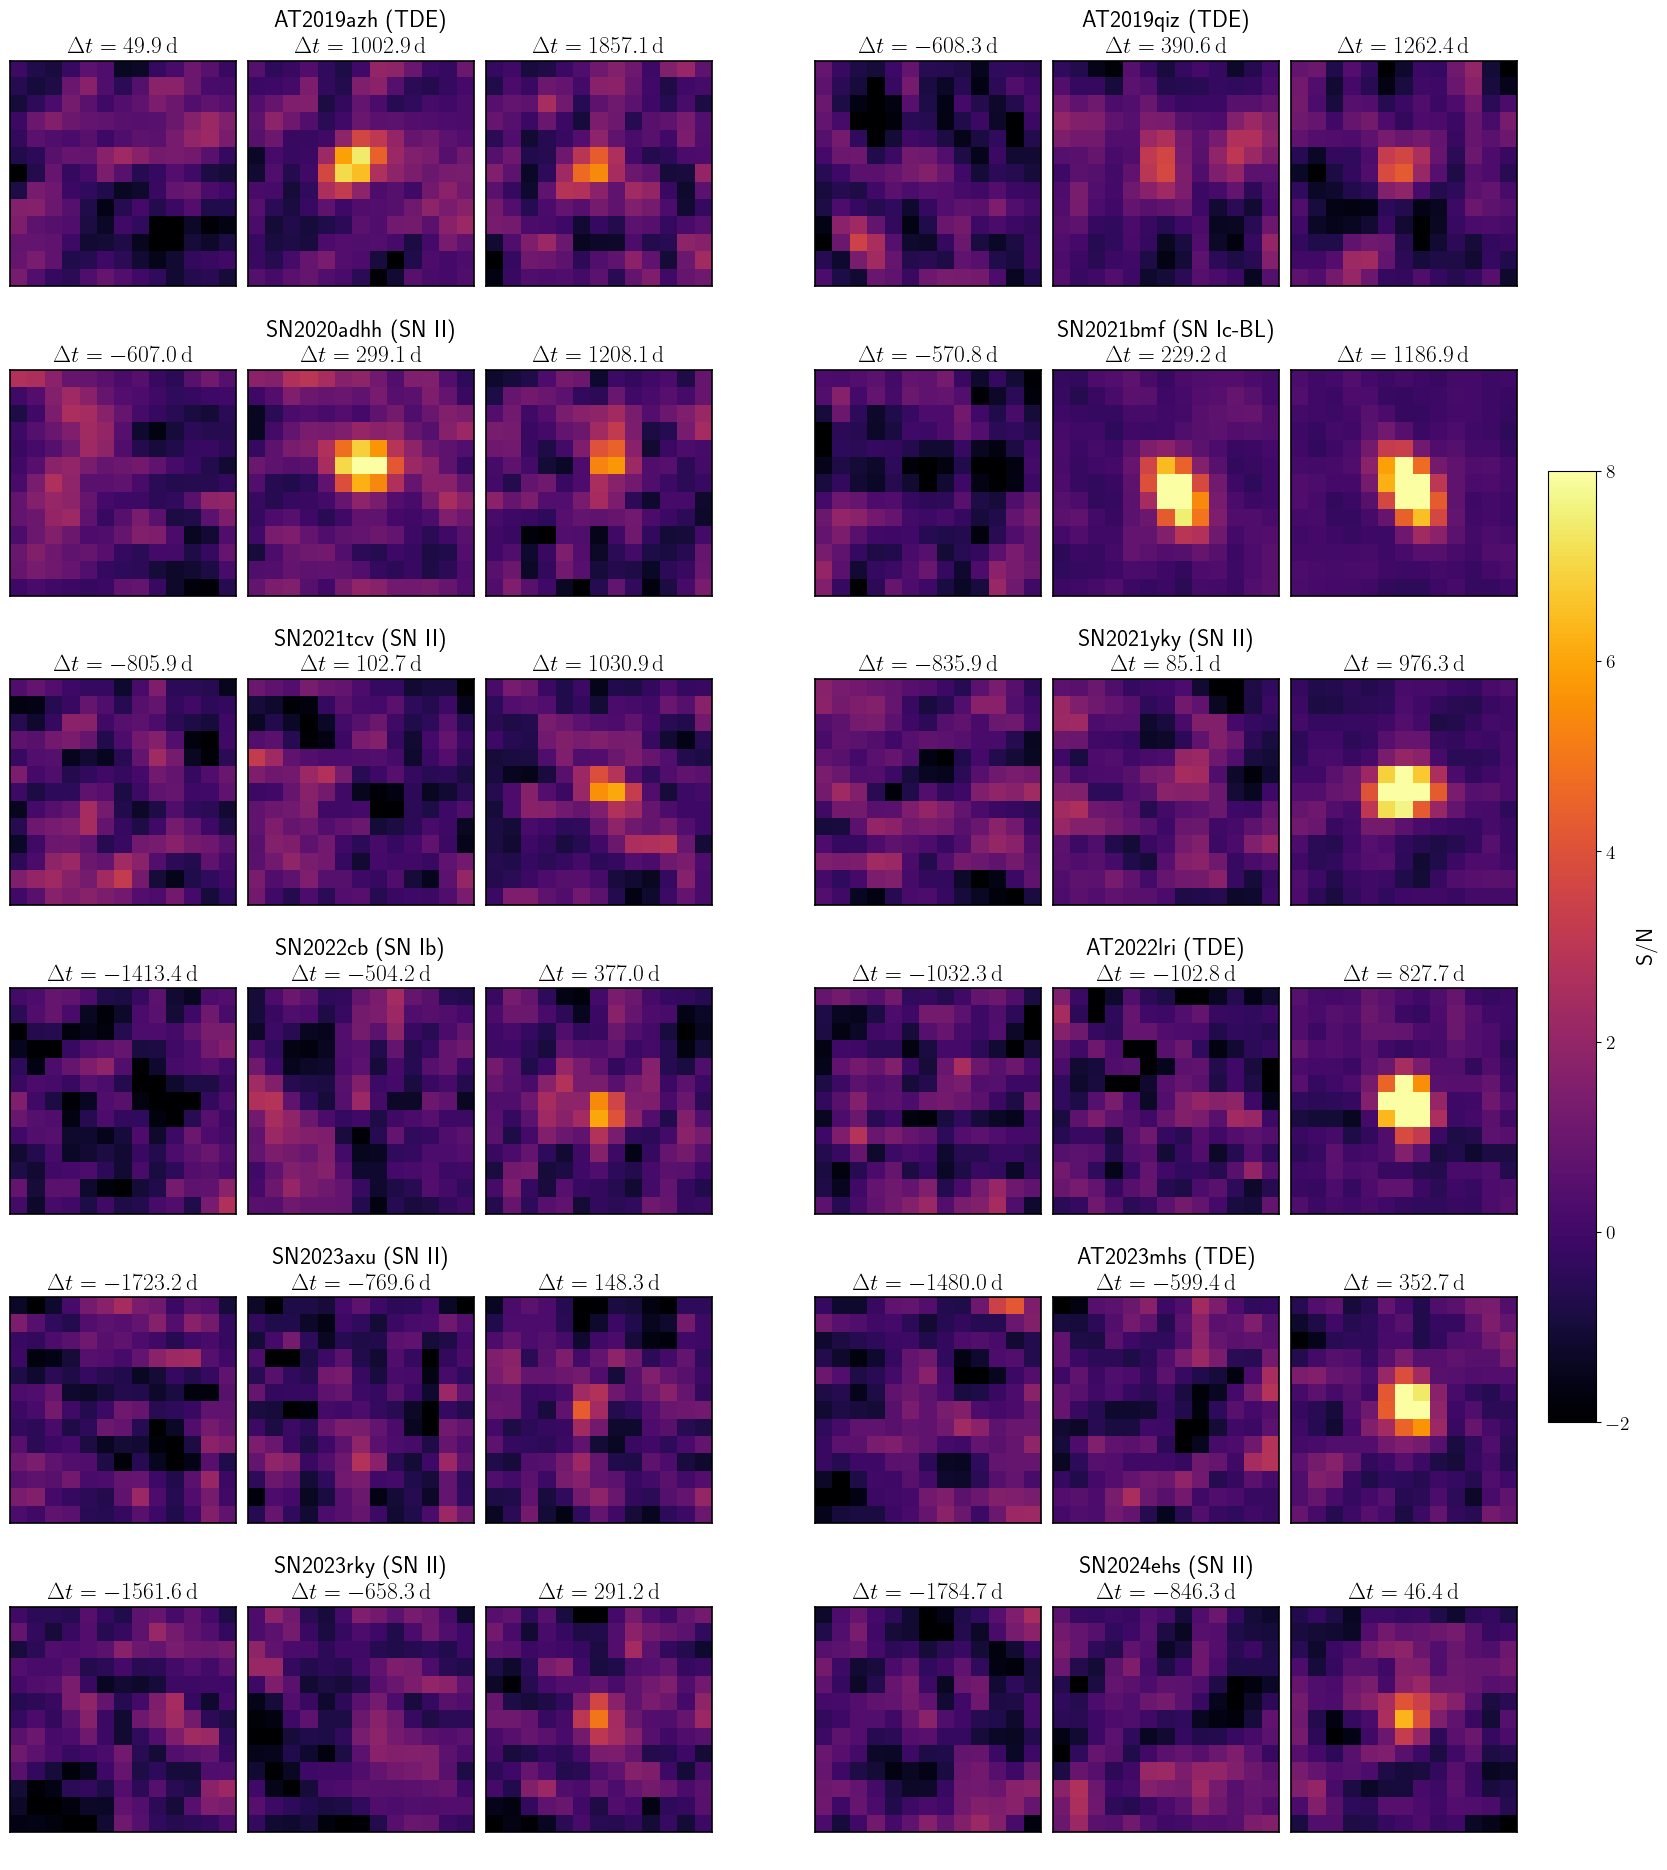

In [55]:
chunk_size = 14

splits = [
    detections_ids[i:i + chunk_size]
    for i in range(0, len(detections_ids), chunk_size)
]
for i, chunk in enumerate(splits, start=1):
    plot_detection_objects_six_wide(
        full_df,
        list(chunk),
        savepath=f"detections_part{i}.pdf"
    )

In [43]:
def build_detection_table(
    full_df,
    detections_ids,
    *,
    name_col="Name",
    epoch_col="Epoch",
    dt_col="Rest_DeltaT",
    rms_col="RMS",
    peak_col="Peak Luminosity",
    type_col="type"
):
    sub = full_df[full_df[name_col].isin(detections_ids)].copy()

    if sub.empty:
        raise ValueError("No rows matched detections_ids.")

    sub = sub.sort_values([name_col, epoch_col])

    rows = []

    for _, row in sub.iterrows():
        rms = row[rms_col]
        peakL = row[peak_col]

        rows.append({
            "Name": row[name_col],
            "Epoch": row[epoch_col],
            "Type": row[type_col] if type_col in row else "",
            "Delta_t (days)": row[dt_col],
            "Peak Luminosity": peakL,
            "RMS": rms,
            "SNR": peakL / rms if rms != 0 else np.nan
        })

    df = pd.DataFrame(rows)

    return df.sort_values(["Name", "Epoch"])

In [44]:
def format_table(df):
    df = df.copy()

    # 4 significant figures for physical quantities
    df["Peak Luminosity"] = df["Peak Luminosity"].apply(
        lambda x: f"{x:.4g}" if pd.notna(x) else "NaN"
    )
    df["RMS"] = df["RMS"].apply(
        lambda x: f"{x:.4g}" if pd.notna(x) else "NaN"
    )
    df["SNR"] = df["SNR"].apply(
        lambda x: f"{x:.4g}" if pd.notna(x) else "NaN"
    )

    # Δt with 2 decimal places
    df["Delta_t (days)"] = df["Delta_t (days)"].apply(
        lambda x: f"{x:.2f}" if pd.notna(x) else "NaN"
    )

    return df

In [59]:
table_df_fmt = format_table(build_detection_table(full_df, detections_ids))


In [60]:
latex_str = table_df_fmt.to_latex(index=False, escape=False)
print(latex_str)

\begin{tabular}{lrlllll}
\toprule
Name & Epoch & Type & Delta_t (days) & Peak Luminosity & RMS & SNR \\
\midrule
ZTF17aaazdba & 1 & TDE & 49.88 & 5.021e+27 & 2.217e+27 & 2.264 \\
ZTF17aaazdba & 2 & TDE & 1002.92 & 1.174e+28 & 1.578e+27 & 7.439 \\
ZTF17aaazdba & 3 & TDE & 1857.12 & 7.425e+27 & 1.361e+27 & 5.456 \\
ZTF18acbwopo & 1 & SN II & 156.09 & 7.495e+28 & 1.842e+28 & 4.069 \\
ZTF18acbwopo & 2 & SN II & 1047.85 & 2.599e+29 & 2.51e+28 & 10.36 \\
ZTF18acbwopo & 3 & SN II & 1909.09 & 3.904e+28 & 2.025e+28 & 1.928 \\
ZTF18acpdvos & 1 & TDE & -291.32 & 8.685e+27 & 6.959e+27 & 1.248 \\
ZTF18acpdvos & 2 & TDE & 645.83 & 2.624e+28 & 7.757e+27 & 3.382 \\
ZTF18acpdvos & 3 & TDE & 1485.43 & 7.49e+29 & 5.426e+28 & 13.8 \\
ZTF19aakkths & 1 & SN IIb & 124.20 & 3.3e+27 & 4.853e+26 & 6.8 \\
ZTF19aakkths & 2 & SN IIb & 960.82 & 8.775e+26 & 5.402e+26 & 1.624 \\
ZTF19aakkths & 3 & SN IIb & 1919.93 & 2.403e+26 & 3.928e+26 & 0.6117 \\
ZTF19aakswrb & 1 & TDE & 32.53 & -1.587e+28 & 4.601e+28 & -0.3449 \\